In [27]:
!uv pip install numpy pandas scikit-learn tensorflow matplotlib --quiet

In [2]:
import numpy as np 
import pandas as pd 

In [3]:
df = pd.read_csv('./churn_modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
4054,4055,15734762,Ignatiev,602,France,Female,56,3,115895.22,3,1,0,4176.17,1
3711,3712,15729489,Hyde,762,Germany,Female,34,8,98592.88,1,0,1,191790.29,1
9976,9977,15656062,Azikiwe,637,France,Female,33,7,103377.81,1,1,0,84419.78,0
4794,4795,15575498,Gould,705,France,Female,39,5,149379.66,2,1,0,96075.55,0
679,680,15668886,Blakey,684,Spain,Female,38,3,0.00,2,1,0,44255.65,0


In [ ]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [6]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [ ]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [15]:
df.shape

(10000, 12)

In [9]:
features = df.drop(columns=['Exited'])
target = df['Exited'].values

from sklearn.model_selection import train_test_split
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=0)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features_train_trf = scaler.fit_transform(features_train)
features_test_trf = scaler.transform(features_test)

In [13]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(11, activation='sigmoid', input_dim=11))
model.add(Dense(11, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/Users/kevin/Desktop/ai-engineer/deep-learning/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(features_train, target_train, batch_size=50, epochs=100, verbose=1, validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step - accuracy: 0.7945 - loss: 0.5677 - val_accuracy: 0.7969 - val_loss: 0.5112
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - accuracy: 0.7958 - loss: 0.5070 - val_accuracy: 0.7969 - val_loss: 0.5030
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.7958 - loss: 0.5047 - val_accuracy: 0.7969 - val_loss: 0.5017
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.7958 - loss: 0.5036 - val_accuracy: 0.7969 - val_loss: 0.5007
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - accuracy: 0.7958 - loss: 0.5032 - val_accuracy: 0.7969 - val_loss: 0.5001
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - accuracy: 0.7958 - loss: 0.5029 - val_accuracy: 0.7969 - val_loss: 0.4997
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.7958 - loss: 0.5027 - val_accuracy: 0.7969 - val_loss: 0.4996
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - accuracy: 0.7958 - loss: 0

In [23]:
target_pred = model.predict(features_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 283us/step


In [24]:
target_pred = target_pred.argmax(axis=-1)
target_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(target_test, target_pred)

0.7975

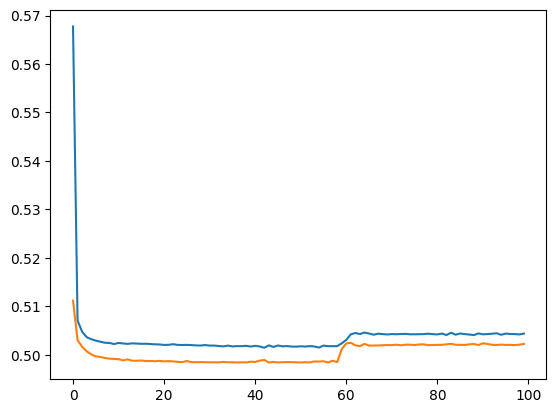

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

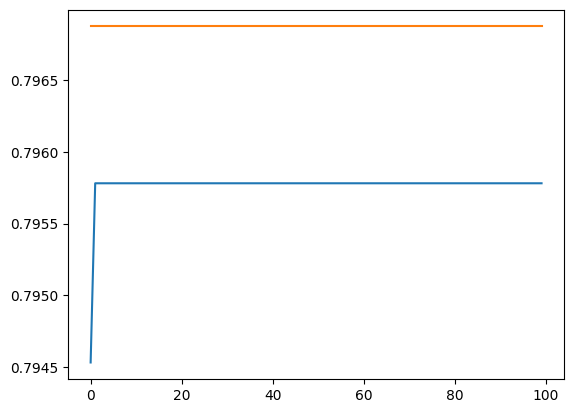

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])